<a href="https://colab.research.google.com/github/junseok-jay/AI_lab/blob/main/week10/efficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# cuDNN을 사용하여 Convolution 연산 최적화 설정
cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
import zipfile
import os

# ZIP 압축 해제하는 함수
def extract_zip_file(zip_file_path, extraction_path):
    """ZIP 파일을 지정된 경로에 압축 해제합니다."""
    os.makedirs(extraction_path, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)
        print(f"Successfully extracted {zip_file_path} to {extraction_path}")
    except FileNotFoundError:
        print(f"Error: The file '{zip_file_path}' was not found.")
        raise
    except zipfile.BadZipFile:
        print(f"Error: The file '{zip_file_path}' is not a valid zip file or is corrupted.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")
        raise

# 데이터셋을 로드하는 함수
def load_image_datasets(data_dir, data_transforms):
    """디렉토리에서 이미지 데이터셋을 로드합니다."""
    try:
        image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                                  data_transforms[x])
                          for x in ['train', 'val']}
        dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                                     shuffle=True, num_workers=2)
                      for x in ['train', 'val']}
        dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
        class_names = image_datasets['train'].classes
        return image_datasets, dataloaders, dataset_sizes, class_names
    except Exception as e:
        print(f"An error occurred during dataset loading: {e}")
        raise

# 파일 경로 정의
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/AI_lab/week10/hymenoptera_data.zip'
extraction_path = './content/data'
data_dir = os.path.join(extraction_path, 'hymenoptera_data')

# 학습을 위한 데이터 증강 및 정규화
# 검증을 위한 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 데이터셋 압축 해제, 로딩
extract_zip_file(zip_file_path, extraction_path)
image_datasets, dataloaders, dataset_sizes, class_names = load_image_datasets(data_dir, data_transforms)

# 사용할 장치 (GPU 또는 CPU) 결정, cuda 사용
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Successfully extracted /content/drive/MyDrive/Colab Notebooks/AI_lab/week10/hymenoptera_data.zip to ./content/data
Using cuda device


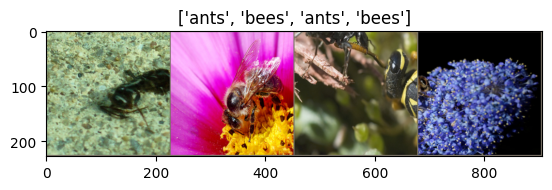

In [3]:
# 텐서 이미지를 표시하는 함수
def imshow(inp, title=None):
    """텐서 이미지를 표시합니다."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # 플롯 업테이트를 위한 대기


# 학습 데이터 배치 가져오기
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [4]:
# 모델 학습 함수
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [5]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()


    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)


            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])


                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [6]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
# model_load = models.resnet18(weights='IMAGENET1K_V1')
# num_ftrs = model_load.fc.in_features

model_load = models.efficientnet_b3(weights='IMAGENET1K_V1')
num_ftrs = model_load.classifier[1].in_features

model_load.fc = nn.Linear(num_ftrs, 2)

model_load = model_load.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_load.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 115MB/s]


In [7]:
# 모델 학습 시작 (25 에포크)
my_model = train_model(model_load, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 3.5937 Acc: 0.4016
val Loss: 2.2583 Acc: 0.5686

Epoch 1/24
----------
train Loss: 0.5739 Acc: 0.7869
val Loss: 1.0429 Acc: 0.7190

Epoch 2/24
----------
train Loss: 0.5613 Acc: 0.7951
val Loss: 0.9792 Acc: 0.8105

Epoch 3/24
----------
train Loss: 0.5358 Acc: 0.7705
val Loss: 0.7991 Acc: 0.8431

Epoch 4/24
----------
train Loss: 0.3350 Acc: 0.8689
val Loss: 0.7583 Acc: 0.8497

Epoch 5/24
----------
train Loss: 0.3594 Acc: 0.8320
val Loss: 0.8400 Acc: 0.8431

Epoch 6/24
----------
train Loss: 0.4465 Acc: 0.7623
val Loss: 0.5252 Acc: 0.8562

Epoch 7/24
----------
train Loss: 0.4552 Acc: 0.8074
val Loss: 0.5477 Acc: 0.8758

Epoch 8/24
----------
train Loss: 0.2808 Acc: 0.8689
val Loss: 0.5928 Acc: 0.8627

Epoch 9/24
----------
train Loss: 0.3802 Acc: 0.8115
val Loss: 0.5464 Acc: 0.8758

Epoch 10/24
----------
train Loss: 0.3182 Acc: 0.8648
val Loss: 0.7203 Acc: 0.8366

Epoch 11/24
----------
train Loss: 0.3730 Acc: 0.8238
val Loss: 0.5484 Acc: 0.8758

Ep

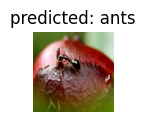

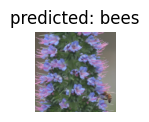

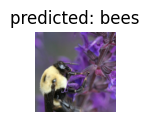

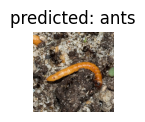

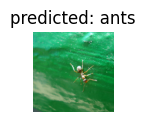

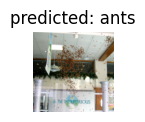

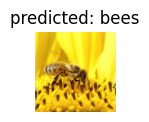

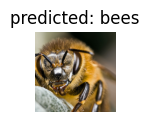

In [8]:
# 학습된 모델의 예측 결과를 시각화 (16개의 이미지)
visualize_model(my_model, num_images=16)

In [9]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')

for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [10]:
# 정의된 함수와 파라미터를 사용하여 컨볼루션 모델 학습 시작 (25 에포크)
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6293 Acc: 0.6680
val Loss: 0.4041 Acc: 0.8105

Epoch 1/24
----------
train Loss: 0.7220 Acc: 0.7213
val Loss: 0.1596 Acc: 0.9608

Epoch 2/24
----------
train Loss: 0.4527 Acc: 0.8197
val Loss: 0.1565 Acc: 0.9412

Epoch 3/24
----------
train Loss: 0.6178 Acc: 0.7746
val Loss: 0.6270 Acc: 0.7712

Epoch 4/24
----------
train Loss: 0.5134 Acc: 0.7910
val Loss: 0.1597 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.3071 Acc: 0.8320
val Loss: 0.1898 Acc: 0.9346

Epoch 6/24
----------
train Loss: 0.4540 Acc: 0.7787
val Loss: 0.2054 Acc: 0.9412

Epoch 7/24
----------
train Loss: 0.3129 Acc: 0.8566
val Loss: 0.1918 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3053 Acc: 0.8484
val Loss: 0.1757 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.2819 Acc: 0.8648
val Loss: 0.1878 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.3226 Acc: 0.8402
val Loss: 0.2013 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.3161 Acc: 0.8525
val Loss: 0.1917 Acc: 0.9346

Ep

In [11]:
# 단일 이미지에 대한 모델 예측을 시각화하는 함수
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    # 이미지 로드 및 전처리
    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

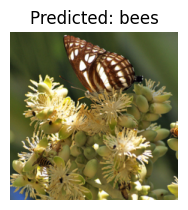

In [15]:
# 컨볼루션 모델을 사용하여 특정 이미지에 대한 예측 시각화
img_path='/content/content/data/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'

visualize_model_predictions(model_conv, img_path)

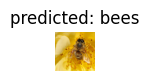

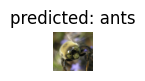

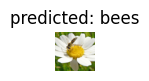

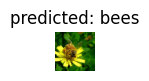

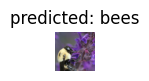

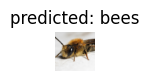

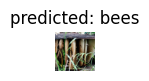

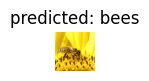

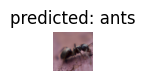

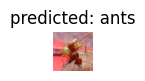

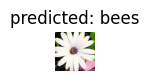

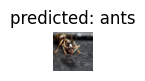

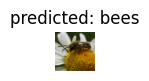

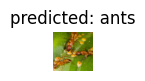

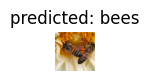

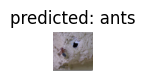

In [13]:
# 컨볼루션 모델을 사용하여 여러 이미지에 대한 예측 시각화
visualize_model(model_conv, num_images=16)